**Mahan Madani - 830504035**

Assignment 3 | Question 2: Image Classification with CNN

## Table of Contents

- [Import libraries and Custom Classes](#import-libraries-and-load-data)
- [Helper Classes and Functions](#helper-classes-and-functions)
    - [Training Functions](#training-functions)
    - [Model Definitions](#model-definitions)
    - [Plotting Functions](#plotting-functions)
- [2.1 Model with 2 Conv Layers (64-32) and Kernel Size = 4*4](#21-model-with-2-conv-layers-64-32-and-kernel-size--44)
- [2.2 Model with 2 Conv Layers (32-32), Kernel Size 4*4, and Dropout = 0.3](#22-model-with-2-conv-layers-32-32-kernel-size-44-and-dropout--03)
- [2.3 Model with 3 Conv Layers (32-32-32) and Kernel Size = 3*3](#23-model-with-3-conv-layers-32-32-32-and-kernel-size--33)
- [2.4 Model with 4 Conv Layers (32-32-32-32) and Kernel Size = 3*3](#24-model-with-4-conv-layers-32-32-32-32-and-kernel-size--33)
- [2.5 Model with 4 Conv Layers and Batch Normalization Layers](#25-model-with-4-conv-layers-and-batch-normalization-layers)
- [Model Comparison](#model-comparison)
- [2.6 Training with Different Learning Rates](#26-training-with-different-learning-rates)
    - [Learning Rate = 0.0001](#learning-rate--00001)
    - [Learning Rate = 0.1](#learning-rate--01)
- [2.7 Training with Different Activation Functions](#27-training-with-different-activation-functions)
    - [Activation Function: Leaky ReLU](#activation-function-leaky-relu)
    - [Activation Function: Swish](#activation-function-swish)
- [2.8 Training with Different Optimizers](#28-training-with-different-optimizers)
    - [Optimizer: SGD](#optimizer-sgd)
    - [Optimizer: AdamW](#optimizer-adamw)
- [2.9 Training with Different Batch Sizes](#29-training-with-different-batch-sizes)
    - [Batch Size = 4](#batch-size--4)
    - [Batch Size = 128](#batch-size--128)
- [Choosing the Best Model](#choosing-the-best-model)
- [2.10 Visualize Feature Maps and Kernels](#210-visualize-feature-maps-and-kernels)
- [2.11 Model Prediction Comparison with Ground Truth](#211-model-prediction-comparison-with-ground-truth)
- [2.12 Confusion Matrix](#212-confusion-matrix)
- [2.13 Transfer Learning](#213-transfer-learning)
    - [ResNet50](#resnet50)
    - [EfficientNetB0](#efficientnetb0)
    - [Comparison](#comparison)


## Import Libraries and Load Data

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import os
import time
import math
import random
import copy
import json

# from tqdm.notebook import tqdm
# from tqdm.auto import tqdm
from tqdm import tqdm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import transforms, datasets, models

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

Data Normalization for CIFAR-10:
<br>Use the CIFAR-10 **training set**’s mean and std to normalize both the train and test dataset.

Data Augmentation Techniques:
<br>- Random Crop (with padding) - It simulates small translations / shifts of the image.
<br>- Random Horizontal Flip - Allows the model to learn mirrored versions of images (0.5 chance)
<br>These techniques don’t modify the dataset permanently, they create slightly altered versions on the fly, every epoch.

In [4]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

DATA_DIR = "./Dataset"
train_data = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_transform)

Randomly separate 10% of the training data as the validation subset, and keep the rest as the train subset

In [5]:
val_split = 0.1

n_val = int(len(train_data) * val_split)
n_train = len(train_data) - n_val
train_subset, val_subset = random_split(train_data, [n_train, n_val])

In [6]:
print('Total train data:       ', len(train_data))
print('Train subset size:      ', len(train_subset))
print('Validation subset size: ', len(val_subset))
print('Total test data:        ', len(test_data))

Total train data:        50000
Train subset size:       45000
Validation subset size:  5000
Total test data:         10000


In order to display the images (required later), their values must be unnormalized first. This fundction reverses the normalization done to a single image tensor.

In [7]:
def unnormalize(img, std=CIFAR10_STD, mean=CIFAR10_MEAN):
    std  = torch.tensor(std, dtype=torch.float32)
    mean = torch.tensor(mean, dtype=torch.float32)
    return img * std[:, None, None] + mean[:, None, None]

## Helper Classes and Functions

### Training Functions

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    total_loss = 0
    total_correct = 0
    total = 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
    
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total

In [9]:
def eval_model(model, loader, criterion, device=DEVICE, return_preds=False):
    model.eval()
    total_loss = 0
    total_correct = 0
    total = 0
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * x.size(0)
            total_correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

            preds_all.append(out.argmax(1).cpu().numpy())
            labels_all.append(y.cpu().numpy())

    if total == 0:
        return None, None, None, None
    elif return_preds:
        return (
            total_loss / total,
            total_correct / total,
            np.concatenate(preds_all),
            np.concatenate(labels_all),
        )
    else:
        return (
            total_loss / total,
            total_correct / total,
        )

In [10]:
def train_and_evaluate(model, trainset, valset, testset,
                       epochs=10, batch_size=32, lr=1e-3, optimizer_name='adam'):
    
    criterion = nn.CrossEntropyLoss()

    num_workers = 2
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True , num_workers=num_workers)
    val_loader   = DataLoader(valset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

    # Optimizer
    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError("Unknown optimizer")

    history = {"train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": []}

    model = model.to(DEVICE)
    start = time.time()

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = eval_model(model, val_loader, criterion, return_preds=False)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        # if (epoch + 1) % math.ceil(epochs/10) == 0:  # print 10 epoch results
        print(f"Epoch {epoch+1:2}/{epochs:2} | "
            f"train_loss={tr_loss:.6f} acc={tr_acc:.6f} | "
            f"val_loss={val_loss:.6f} acc={val_acc:.6f}")

    total_time = time.time() - start

    test_loss, test_acc, preds, labels = eval_model(model, test_loader, criterion, return_preds=True)
    print(f"\nTest: loss={test_loss:.6f}, acc={test_acc:.6f}")

    results = {
        "model": model,
        "history": history,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_preds": preds,
        "test_labels": labels,
        "time_sec": total_time,
    }
    
    return results
 

### Model Definitions

Each Convolution Block contains a Convolutional layer with an activation function (ReLU, Leaky ReLU, or Swish). It may also have a max pool layer (size 2*2) and a batch normalization layer as well.

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, activation='relu', batchnorm=False, pooling=False):
        super().__init__()
        
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size // 2, stride=1)
        self.bn = nn.BatchNorm2d(out_ch) if batchnorm else None

        activation = activation.lower()
        if activation == 'relu':
            self.act = nn.ReLU(inplace=True)
        elif activation == 'leaky':
            self.act = nn.LeakyReLU(0.1, inplace=True)  # Leaky ReLU with leakage=0.1
        elif activation == 'swish':
            self.act = nn.SiLU(inplace=True)  # Swish
        else:
            raise ValueError("Unknown activation")

        self.pool = nn.MaxPool2d(2) if pooling else None

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x) if self.bn is not None else x
        x = self.act(x)
        x = self.pool(x) if self.pool is not None else x
        return x

The models are created using the CNN class, which receives a list of Convolutional Blocks (used for feature extraction) and feeds the feature vector to a 2-layered Fully Connected Network with 256 hidden neurons and 10 output neurons.


In [12]:
class CNN(nn.Module):
    def __init__(self, convolution_blocks, dropout_prob=0.0):
        super().__init__()
        
        self.features = nn.Sequential(*convolution_blocks)

        self.flat_size = self.get_flattened_size()
    
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 10),
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
    def get_flattened_size(self):  # Pass a dummy tensor through self.features to determine output size of the CNN.
        x = torch.zeros(1, 3, 32, 32)   # CIFAR-10 dummy input
        with torch.no_grad():
            x = self.features(x)
        return x.numel()      

### Plotting Functions

In [13]:
def plot_history(history):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train")
    plt.plot(epochs, history["val_acc"], label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

In [14]:
def plot_confusion_matrix_cm(y_true, y_pred, classes=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(7,7))
    disp.plot(ax=ax, xticks_rotation=90, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

## 2.1 Model with 2 Conv Layers (64-32) and Kernel Size = 4*4

In [16]:
result_list = []

In [ ]:
conv_blocks = [
    ConvBlock(3,  64, 4, "relu", batchnorm=False, pooling=True),
    ConvBlock(64, 32, 4, "relu", batchnorm=False, pooling=True),
]

model = CNN(conv_blocks)

In [21]:
model

CNN(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 64, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
      (act): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (conv): Conv2d(64, 32, kernel_size=(4, 4), stride=(1, 1), padding=(2, 2))
      (act): ReLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [22]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.694420 acc=0.377933 | val_loss=1.532236 acc=0.437200


Epoch  2/10 | train_loss=1.487076 acc=0.458022 | val_loss=1.423765 acc=0.482600


Epoch  3/10 | train_loss=1.405525 acc=0.492622 | val_loss=1.344946 acc=0.507000


Epoch  4/10 | train_loss=1.342766 acc=0.516511 | val_loss=1.326608 acc=0.526600


Epoch  5/10 | train_loss=1.308803 acc=0.528956 | val_loss=1.275578 acc=0.542800


...

Epoch  7/10 | train_loss=1.232752 acc=0.558022 | val_loss=1.219387 acc=0.568800


Epoch  8/10 | train_loss=1.211910 acc=0.566200 | val_loss=1.181453 acc=0.581600


Epoch  9/10 | train_loss=1.189383 acc=0.577222 | val_loss=1.201919 acc=0.567000


Epoch 10/10 | train_loss=1.170418 acc=0.586511 | val_loss=1.175335 acc=0.583600

Test: loss=1.127813, acc=0.600800


245.88300704956055

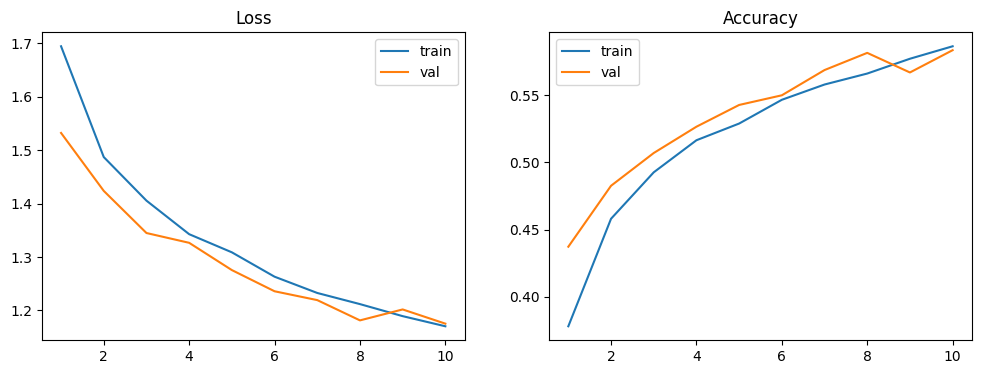

In [23]:
plot_history(results['history']) 

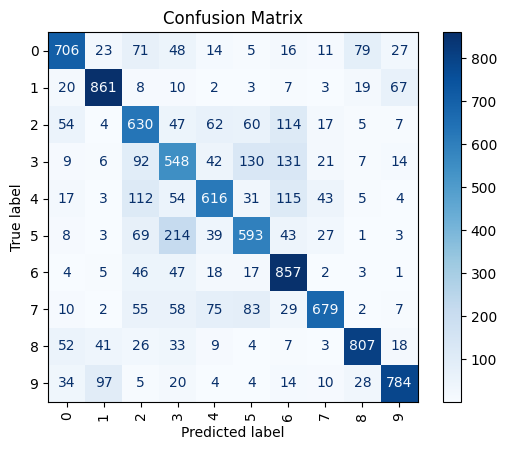

In [28]:
plot_confusion_matrix_cm(y_true=results['test_labels'], y_pred=results['test_preds'], classes=[i for i in range(10)])

In [24]:
results.keys()

dict_keys(['model', 'history', 'test_loss', 'test_acc', 'test_preds', 'test_labels', 'time_sec'])

## 2.2 Model with 2 Conv Layers (32-32), Kernel Size 4*4, and Dropout = 0.3

In [ ]:
conv_blocks = [
    ConvBlock(3,  32, 4, "relu", batchnorm=False, pooling=True),
    ConvBlock(32, 32, 4, "relu", batchnorm=False, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [26]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.585709 acc=0.423756 | val_loss=1.372389 acc=0.513000


Epoch  2/10 | train_loss=1.296574 acc=0.532600 | val_loss=1.199039 acc=0.569800


Epoch  3/10 | train_loss=1.176113 acc=0.579378 | val_loss=1.052068 acc=0.616200


Epoch  4/10 | train_loss=1.108508 acc=0.608667 | val_loss=0.998019 acc=0.645800


Epoch  5/10 | train_loss=1.067046 acc=0.622489 | val_loss=1.005472 acc=0.634200


...

Epoch  7/10 | train_loss=1.002038 acc=0.646600 | val_loss=0.941112 acc=0.664800


Epoch  8/10 | train_loss=0.977864 acc=0.657556 | val_loss=0.971509 acc=0.655200


Epoch  9/10 | train_loss=0.962684 acc=0.662444 | val_loss=0.870137 acc=0.694400


Epoch 10/10 | train_loss=0.939412 acc=0.671711 | val_loss=0.883332 acc=0.689200

Test: loss=0.839519, acc=0.708100


244.23029851913452

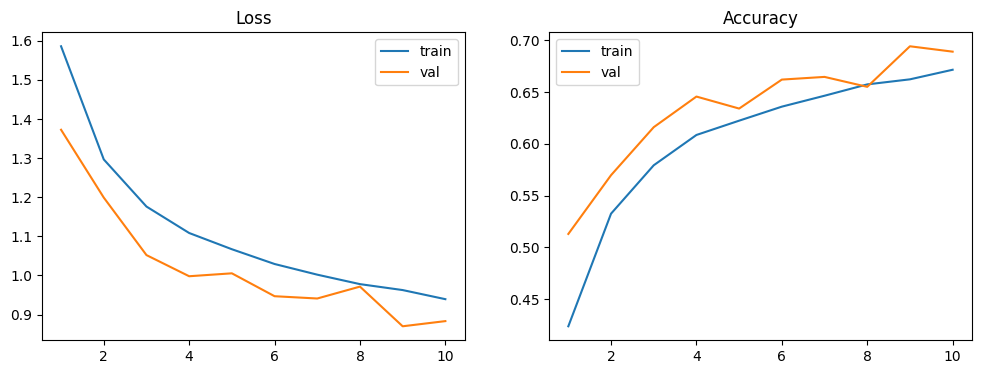

In [27]:
plot_history(results['history']) 

## 2.3 Model with 3 Conv Layers (32-32-32) and Kernel Size = 3*3

In [29]:
conv_blocks = [
    ConvBlock(3,  32, 3, "relu", batchnorm=False, pooling=True),
    ConvBlock(32, 32, 3, "relu", batchnorm=False, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=False, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [30]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.616271 acc=0.404844 | val_loss=1.414310 acc=0.484800


Epoch  2/10 | train_loss=1.319460 acc=0.520822 | val_loss=1.187463 acc=0.560400


Epoch  3/10 | train_loss=1.182419 acc=0.576178 | val_loss=1.097733 acc=0.608600


Epoch  4/10 | train_loss=1.095693 acc=0.611578 | val_loss=0.987795 acc=0.647000


Epoch  5/10 | train_loss=1.029742 acc=0.638289 | val_loss=0.947923 acc=0.666000


...

Epoch  7/10 | train_loss=0.950274 acc=0.665400 | val_loss=0.881441 acc=0.687600


Epoch  8/10 | train_loss=0.925794 acc=0.675622 | val_loss=0.887188 acc=0.686200


Epoch  9/10 | train_loss=0.896300 acc=0.686689 | val_loss=0.851582 acc=0.701000


Epoch 10/10 | train_loss=0.877659 acc=0.695244 | val_loss=0.827973 acc=0.705400

Test: loss=0.772828, acc=0.734800


251.46719670295715

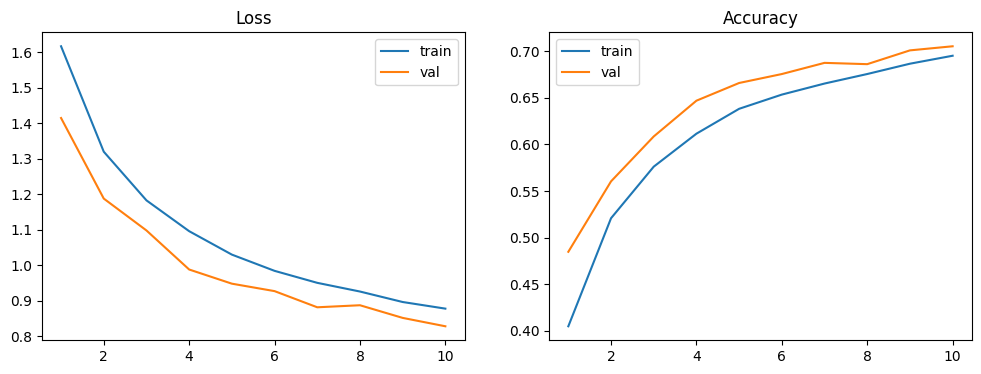

In [31]:
plot_history(results['history']) 

## 2.4 Model with 4 Conv Layers (32-32-32-32) and Kernel Size = 3*3

In [32]:
conv_blocks = [
    ConvBlock(3,  32, 3, "relu", batchnorm=False, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=False, pooling=True),
    ConvBlock(32, 32, 3, "relu", batchnorm=False, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=False, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [33]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.601423 acc=0.407822 | val_loss=1.375443 acc=0.506000


Epoch  2/10 | train_loss=1.246830 acc=0.548000 | val_loss=1.084597 acc=0.610000


Epoch  3/10 | train_loss=1.079973 acc=0.617178 | val_loss=0.993650 acc=0.646400


Epoch  4/10 | train_loss=0.981898 acc=0.651644 | val_loss=0.880928 acc=0.686800


Epoch  5/10 | train_loss=0.928637 acc=0.673889 | val_loss=0.881775 acc=0.688800


...

Epoch  7/10 | train_loss=0.851686 acc=0.698733 | val_loss=0.785657 acc=0.714600


Epoch  8/10 | train_loss=0.822868 acc=0.713178 | val_loss=0.820385 acc=0.707800


Epoch  9/10 | train_loss=0.808353 acc=0.717289 | val_loss=0.781322 acc=0.731800


Epoch 10/10 | train_loss=0.784156 acc=0.723756 | val_loss=0.769997 acc=0.731800

Test: loss=0.722008, acc=0.748800


247.98450183868408

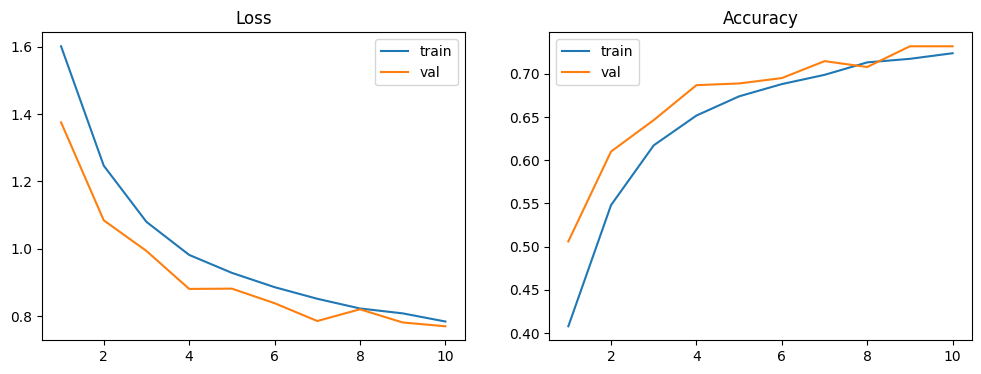

In [34]:
plot_history(results['history']) 

## 2.5 Model with 4 Conv Layers and Batch Normalization Layers

In [45]:
conv_blocks = [
    ConvBlock(3,  32, 3, "relu", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [46]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.546325 acc=0.430667 | val_loss=1.282112 acc=0.532200


Epoch  2/10 | train_loss=1.190462 acc=0.574222 | val_loss=1.162675 acc=0.597400


Epoch  3/10 | train_loss=1.071831 acc=0.617778 | val_loss=0.955200 acc=0.651600


Epoch  4/10 | train_loss=0.989318 acc=0.647333 | val_loss=0.901397 acc=0.669400


Epoch  5/10 | train_loss=0.930163 acc=0.674111 | val_loss=0.815434 acc=0.699000


...

Epoch  7/10 | train_loss=0.857323 acc=0.697756 | val_loss=0.815852 acc=0.705600


Epoch  8/10 | train_loss=0.827744 acc=0.710000 | val_loss=0.741275 acc=0.740600


Epoch  9/10 | train_loss=0.803323 acc=0.717022 | val_loss=0.729197 acc=0.731600


Epoch 10/10 | train_loss=0.784830 acc=0.726200 | val_loss=0.712987 acc=0.742600

Test: loss=0.673010, acc=0.769000


282.2716908454895

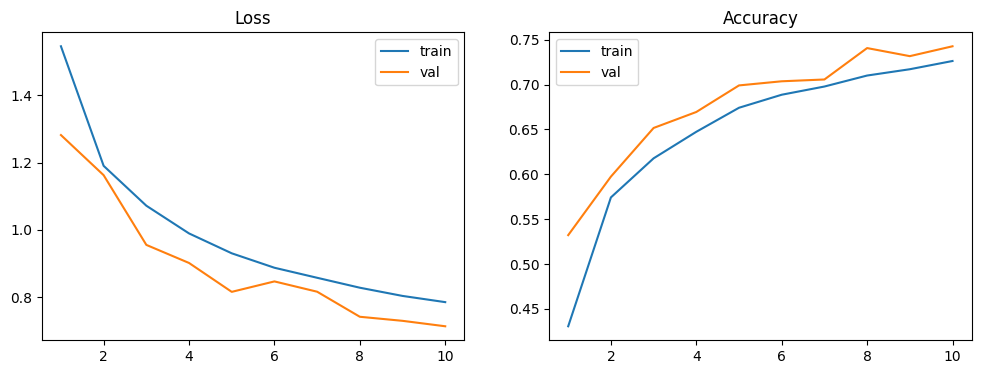

In [47]:
plot_history(results['history']) 

## Model Comparison

In [ ]:
print( 'Test Accuracy Comparison:\n\n' +
       '                     Model                       | Test Accuracy\n' +
       '------------------------------------------------------------------\n' +
      f' 64-32       , k=4*4 , dropout=0.0               |  {result_list[0]['test_acc']} \n' +
      f' 32-32       , k=4*4 , dropout=0.3               |  {result_list[1]['test_acc']} \n' +
      f' 32-32-32    , k=3*3 , dropout=0.3               |  {result_list[2]['test_acc']} \n' +
      f' 32-32-32-32 , k=3*3 , dropout=0.3               |  {result_list[3]['test_acc']} \n' +
      f' 32-32-32-32 , k=3*3 , dropout=0.3 , batch_norm  |  {result_list[4]['test_acc']}')

Test Accuracy Comparison:

                     Model                       | Test Accuracy
------------------------------------------------------------------
 64-32       , k=4*4 , dropout=0.0               |  0.6008 
 32-32       , k=4*4 , dropout=0.3               |  0.7081 
 32-32-32    , k=3*3 , dropout=0.3               |  0.7348 
 32-32-32-32 , k=3*3 , dropout=0.3               |  0.7488 
 32-32-32-32 , k=3*3 , dropout=0.3 , batch_norm  |  0.769


The best arhcitecure so far belongs to the final model (32-32-pool-32-32-pool) utilizing batch norm layers and the dropout technique.

## 2.6 Training with Different Learning Rates

### Learning rate = 0.0001

In [48]:
conv_blocks = [
    ConvBlock(3,  32, 3, "relu", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [49]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.0001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.589338 acc=0.417089 | val_loss=1.314740 acc=0.523400


Epoch  2/10 | train_loss=1.296844 acc=0.531889 | val_loss=1.200366 acc=0.567000


Epoch  3/10 | train_loss=1.164710 acc=0.583600 | val_loss=1.061393 acc=0.616400


Epoch  4/10 | train_loss=1.078697 acc=0.616667 | val_loss=1.019425 acc=0.632600


Epoch  5/10 | train_loss=1.020546 acc=0.641467 | val_loss=0.952060 acc=0.651000


...

Epoch  7/10 | train_loss=0.929744 acc=0.671378 | val_loss=0.887203 acc=0.685000


Epoch  8/10 | train_loss=0.897250 acc=0.685267 | val_loss=0.846683 acc=0.693000


Epoch  9/10 | train_loss=0.871257 acc=0.691511 | val_loss=0.843868 acc=0.706000


Epoch 10/10 | train_loss=0.844699 acc=0.703889 | val_loss=0.815091 acc=0.705600

Test: loss=0.743158, acc=0.737400


281.6432409286499

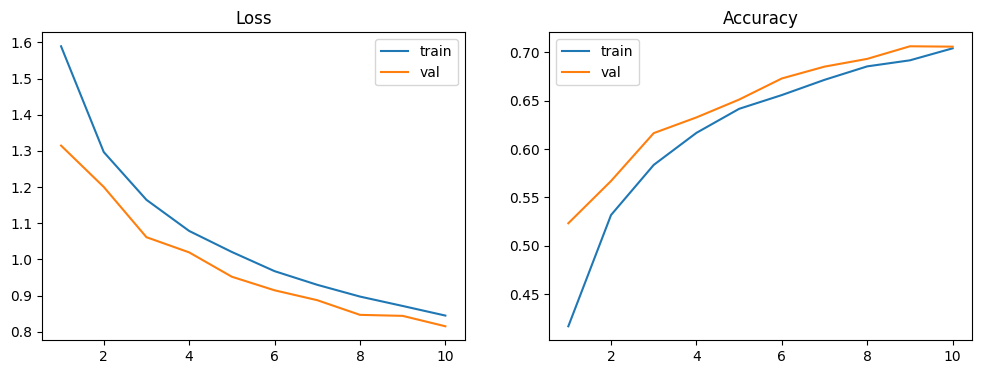

In [50]:
plot_history(results['history']) 

### Learning rate = 0.1

In [51]:
conv_blocks = [
    ConvBlock(3,  32, 3, "relu", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "relu", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [52]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.1, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=3.396692 acc=0.100933 | val_loss=2.311551 acc=0.103400


Epoch  2/10 | train_loss=2.315160 acc=0.099956 | val_loss=2.316158 acc=0.093800


Epoch  3/10 | train_loss=2.315695 acc=0.101778 | val_loss=2.319400 acc=0.098800


Epoch  4/10 | train_loss=2.315587 acc=0.099578 | val_loss=2.329415 acc=0.101600


Epoch  5/10 | train_loss=2.315841 acc=0.100067 | val_loss=2.319826 acc=0.093800


...

Epoch  7/10 | train_loss=2.314674 acc=0.103578 | val_loss=2.313126 acc=0.099000


Epoch  8/10 | train_loss=2.315236 acc=0.099067 | val_loss=2.311506 acc=0.099800


Epoch  9/10 | train_loss=2.315238 acc=0.098778 | val_loss=2.315919 acc=0.093800


Epoch 10/10 | train_loss=2.315646 acc=0.098333 | val_loss=2.317241 acc=0.098400

Test: loss=2.315323, acc=0.100000


285.5262792110443

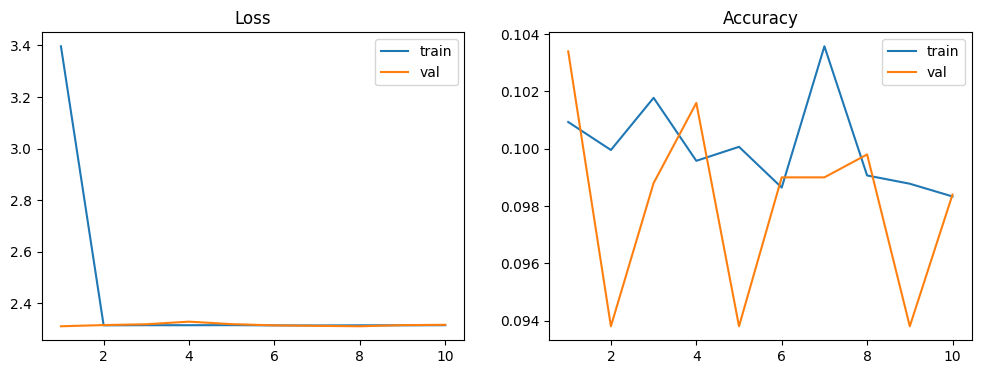

In [53]:
plot_history(results['history']) 

## 2.7 Training with Different Activation Functions

### Activation Function: Leaky ReLU

In [54]:
conv_blocks = [
    ConvBlock(3,  32, 3, "leaky", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "leaky", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "leaky", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "leaky", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [55]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.520720 acc=0.440178 | val_loss=1.263685 acc=0.543600


Epoch  2/10 | train_loss=1.180741 acc=0.575444 | val_loss=1.041655 acc=0.628800


Epoch  3/10 | train_loss=1.042612 acc=0.628600 | val_loss=1.011019 acc=0.631400


Epoch  4/10 | train_loss=0.967598 acc=0.660267 | val_loss=0.888777 acc=0.690400


Epoch  5/10 | train_loss=0.908768 acc=0.681822 | val_loss=0.832011 acc=0.696800


...

Epoch  7/10 | train_loss=0.823271 acc=0.711844 | val_loss=0.831945 acc=0.706600


Epoch  8/10 | train_loss=0.790336 acc=0.723222 | val_loss=0.746559 acc=0.733400


Epoch  9/10 | train_loss=0.762426 acc=0.735133 | val_loss=0.718795 acc=0.741200


Epoch 10/10 | train_loss=0.739559 acc=0.744978 | val_loss=0.675939 acc=0.759600

Test: loss=0.631554, acc=0.779700


276.06054306030273

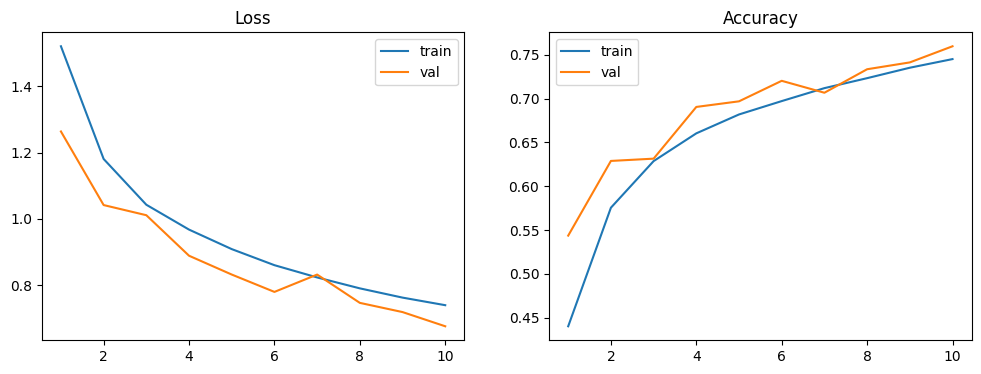

In [56]:
plot_history(results['history']) 

### Activation Function: Swish

In [57]:
conv_blocks = [
    ConvBlock(3,  32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [58]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.447716 acc=0.470978 | val_loss=1.156981 acc=0.583200


Epoch  2/10 | train_loss=1.100179 acc=0.608556 | val_loss=0.951241 acc=0.659800


Epoch  3/10 | train_loss=0.979107 acc=0.654400 | val_loss=0.849884 acc=0.692400


Epoch  4/10 | train_loss=0.910287 acc=0.679889 | val_loss=0.793205 acc=0.715800


Epoch  5/10 | train_loss=0.853422 acc=0.704133 | val_loss=0.790128 acc=0.714200


...

Epoch  7/10 | train_loss=0.779479 acc=0.727422 | val_loss=0.705231 acc=0.752800


Epoch  8/10 | train_loss=0.753740 acc=0.740022 | val_loss=0.677917 acc=0.756800


Epoch  9/10 | train_loss=0.722998 acc=0.748711 | val_loss=0.669549 acc=0.772400


Epoch 10/10 | train_loss=0.714517 acc=0.753756 | val_loss=0.639608 acc=0.777800

Test: loss=0.611933, acc=0.790900


275.96528840065

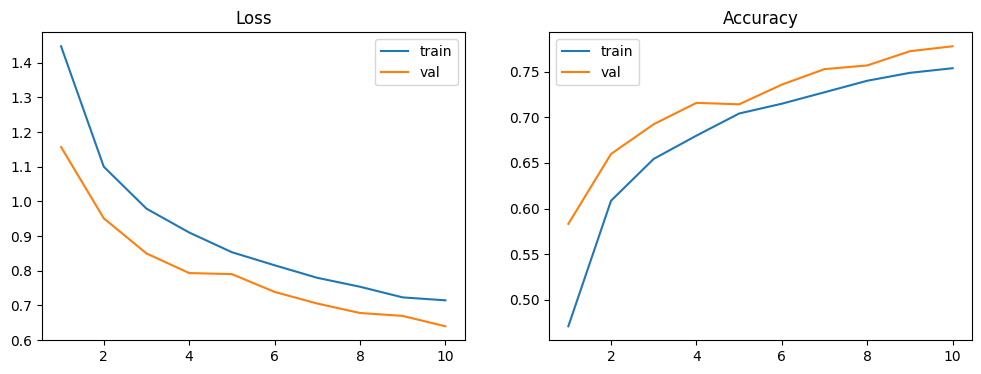

In [59]:
plot_history(results['history']) 

## 2.8 Training with Different Optimizers

### Optimizer: SGD

In [64]:
conv_blocks = [
    ConvBlock(3,  32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [65]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='sgd')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.579114 acc=0.421133 | val_loss=1.309607 acc=0.531000


Epoch  2/10 | train_loss=1.230014 acc=0.557444 | val_loss=1.091820 acc=0.606200


Epoch  3/10 | train_loss=1.091103 acc=0.613422 | val_loss=0.980229 acc=0.657000


Epoch  4/10 | train_loss=0.992824 acc=0.646689 | val_loss=0.919524 acc=0.669600


Epoch  5/10 | train_loss=0.934021 acc=0.669400 | val_loss=0.842627 acc=0.695600


...

Epoch  7/10 | train_loss=0.847589 acc=0.703644 | val_loss=0.763048 acc=0.735200


Epoch  8/10 | train_loss=0.818760 acc=0.713244 | val_loss=0.772752 acc=0.718000


Epoch  9/10 | train_loss=0.785346 acc=0.723400 | val_loss=0.744606 acc=0.734600


Epoch 10/10 | train_loss=0.761042 acc=0.732756 | val_loss=0.709052 acc=0.737200

Test: loss=0.654968, acc=0.770500


262.16778683662415

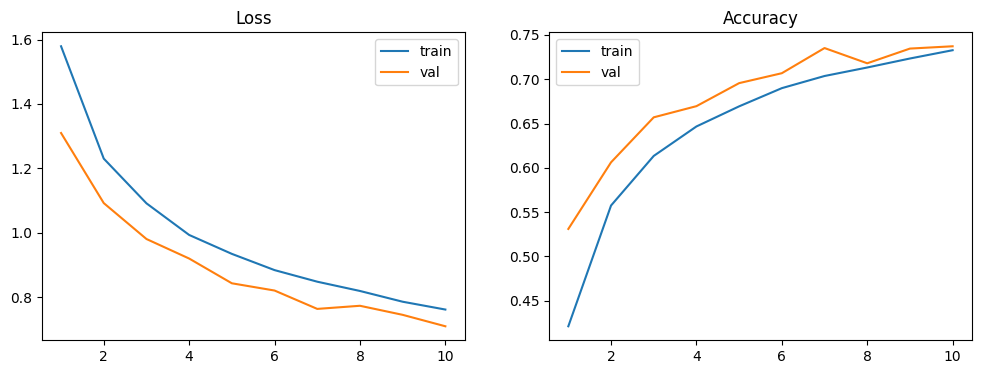

In [66]:
plot_history(results['history']) 

### Optimizer: AdamW

In [67]:
conv_blocks = [
    ConvBlock(3,  32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [68]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=32, lr=0.001, optimizer_name='adamw')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.457037 acc=0.469244 | val_loss=1.116018 acc=0.601000


Epoch  2/10 | train_loss=1.118831 acc=0.601422 | val_loss=0.953670 acc=0.655400


Epoch  3/10 | train_loss=0.979419 acc=0.656711 | val_loss=0.843894 acc=0.689200


Epoch  4/10 | train_loss=0.902786 acc=0.683956 | val_loss=0.918910 acc=0.668600


Epoch  5/10 | train_loss=0.847398 acc=0.704511 | val_loss=0.770273 acc=0.726600


...

Epoch  7/10 | train_loss=0.779416 acc=0.731267 | val_loss=0.699042 acc=0.746600


Epoch  8/10 | train_loss=0.754837 acc=0.737422 | val_loss=0.674975 acc=0.760200


Epoch  9/10 | train_loss=0.731760 acc=0.746067 | val_loss=0.673332 acc=0.764000


Epoch 10/10 | train_loss=0.711425 acc=0.752644 | val_loss=0.677822 acc=0.765400

Test: loss=0.643839, acc=0.781600


259.9271664619446

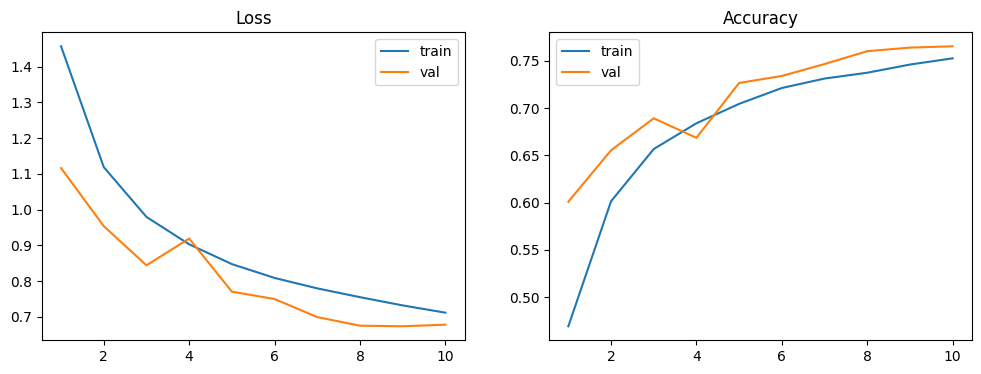

In [69]:
plot_history(results['history']) 

## 2.9 Training with Different Batch Sizes

### Batch Size = 4

In [70]:
conv_blocks = [
    ConvBlock(3,  32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [71]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=4, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.681696 acc=0.388489 | val_loss=1.293180 acc=0.530600


Epoch  2/10 | train_loss=1.302380 acc=0.538022 | val_loss=1.067100 acc=0.623600


Epoch  3/10 | train_loss=1.151446 acc=0.599000 | val_loss=0.971082 acc=0.654200


Epoch  4/10 | train_loss=1.077817 acc=0.625800 | val_loss=0.960806 acc=0.664200


Epoch  5/10 | train_loss=1.027722 acc=0.643444 | val_loss=0.845880 acc=0.702800


...

Epoch  7/10 | train_loss=0.950270 acc=0.673689 | val_loss=0.797707 acc=0.705200


Epoch  8/10 | train_loss=0.920159 acc=0.682444 | val_loss=0.811878 acc=0.718000


Epoch  9/10 | train_loss=0.893117 acc=0.692044 | val_loss=0.781120 acc=0.725800


Epoch 10/10 | train_loss=0.866748 acc=0.700133 | val_loss=0.804959 acc=0.717800

Test: loss=0.764336, acc=0.739900


801.0041494369507

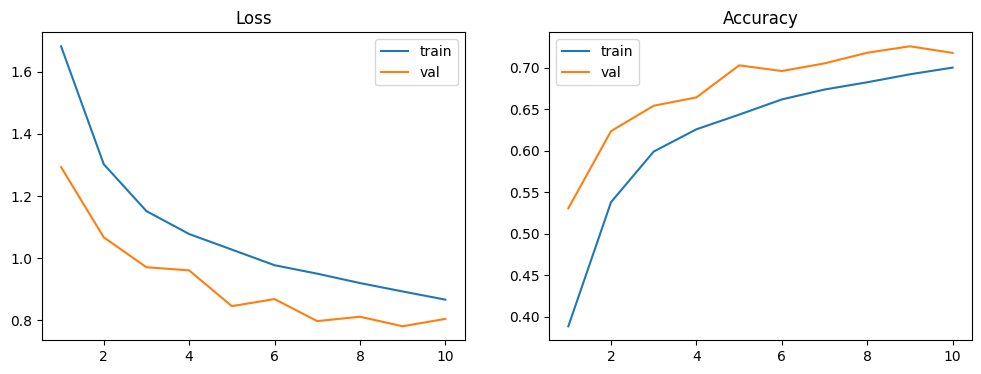

In [72]:
plot_history(results['history']) 

### Batch Size = 128

In [73]:
conv_blocks = [
    ConvBlock(3,  32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

In [74]:
results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=10, batch_size=128, lr=0.001, optimizer_name='adam')

result_list.append(results)
results['time_sec']

Epoch  1/10 | train_loss=1.491913 acc=0.454867 | val_loss=1.216746 acc=0.564400


Epoch  2/10 | train_loss=1.124380 acc=0.597111 | val_loss=1.015904 acc=0.640800


Epoch  3/10 | train_loss=0.973833 acc=0.654756 | val_loss=0.893804 acc=0.680000


Epoch  4/10 | train_loss=0.907374 acc=0.683200 | val_loss=0.993480 acc=0.659000


Epoch  5/10 | train_loss=0.851931 acc=0.699244 | val_loss=0.770893 acc=0.724200


...

Epoch  7/10 | train_loss=0.783366 acc=0.724333 | val_loss=0.746180 acc=0.735000


Epoch  8/10 | train_loss=0.763101 acc=0.734333 | val_loss=0.781124 acc=0.713400


Epoch  9/10 | train_loss=0.736058 acc=0.744378 | val_loss=0.707268 acc=0.747600


Epoch 10/10 | train_loss=0.714622 acc=0.750022 | val_loss=0.678508 acc=0.762800

Test: loss=0.637447, acc=0.776500


240.86954712867737

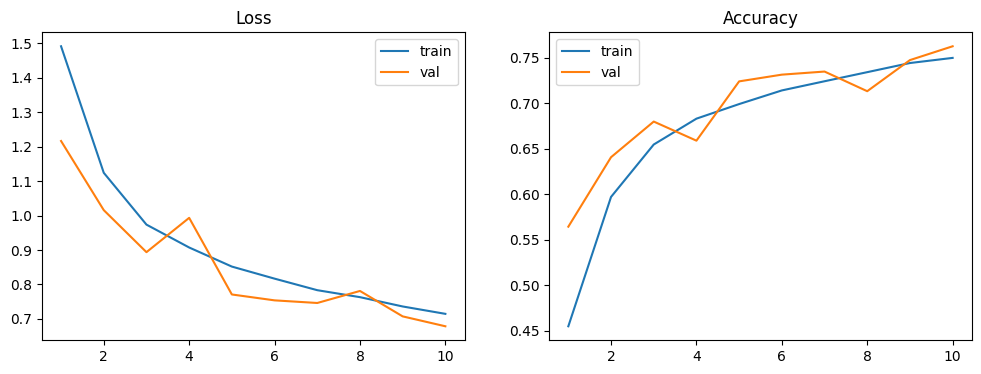

In [75]:
plot_history(results['history']) 

## Choosing the Best Model

Take the model architecture with the best results and train it for a total of 20 epochs. This model will be used for sections 2.10, 2.11, and 2.12.

In [80]:
print( 'Test Accuracy Comparison:\n\n' +
       '   Model (32-32-32-32, k=3*3, dropout=0.3)   | Test Accuracy\n' +
       '-------------------------------------------------------------\n' +
      f' lr=0.001  , ReLU       , Adam  , Batch=32   |  {result_list[4]['test_acc']} \n' +
      f' lr=0.0001 , ReLU       , Adam  , Batch=32   |  {result_list[5]['test_acc']} \n' +
      f' lr=0.001  , ReLU       , Adam  , Batch=32   |  {result_list[6]['test_acc']} \n' +
      f' lr=0.001  , Leaky ReLU , Adam  , Batch=32   |  {result_list[7]['test_acc']} \n' +
      f' lr=0.001  , Swish      , Adam  , Batch=32   |  {result_list[8]['test_acc']} \n' +
      f' lr=0.001  , Swish      , SGD   , Batch=32   |  {result_list[9]['test_acc']} \n' +
      f' lr=0.001  , Swish      , AdamW , Batch=32   |  {result_list[10]['test_acc']} \n' +
      f' lr=0.001  , Swish      , Adam  , Batch=4    |  {result_list[11]['test_acc']} \n' +
      f' lr=0.001  , Swish      , Adam  , Batch=128  |  {result_list[12]['test_acc']}')

Test Accuracy Comparison:

   Model (32-32-32-32, k=3*3, dropout=0.3)   | Test Accuracy
-------------------------------------------------------------
 lr=0.001  , ReLU       , Adam  , Batch=32   |  0.769 
 lr=0.0001 , ReLU       , Adam  , Batch=32   |  0.7374 
 lr=0.001  , ReLU       , Adam  , Batch=32   |  0.1 
 lr=0.001  , Leaky ReLU , Adam  , Batch=32   |  0.7797 
 lr=0.001  , Swish      , Adam  , Batch=32   |  0.7909 
 lr=0.001  , Swish      , SGD   , Batch=32   |  0.7705 
 lr=0.001  , Swish      , AdamW , Batch=32   |  0.7816 
 lr=0.001  , Swish      , Adam  , Batch=4    |  0.7399 
 lr=0.001  , Swish      , Adam  , Batch=128  |  0.7765


The best overall model was 32-32-pool-32-32-pool, k=3*3, dropout=0.3, batch_norm=True, lr=0.001, Swish, Adam, Batch=32    ->    Test accuracy = 0.7909

In [76]:
conv_blocks = [
    ConvBlock(3,  32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=False),
    ConvBlock(32, 32, 3, "swish", batchnorm=True, pooling=True),
]

model = CNN(conv_blocks, dropout_prob=0.3)

results = train_and_evaluate(model, trainset=train_subset, valset=val_subset, testset=test_data,
                              epochs=20, batch_size=32, lr=0.001, optimizer_name='adam')

# result_list.append(results)
results['time_sec']

  0%|          | 0/1407 [00:00<?, ?it/s]

Epoch  1/20 | train_loss=1.480306 acc=0.458889 | val_loss=1.119686 acc=0.597400


Epoch  2/20 | train_loss=1.136459 acc=0.594356 | val_loss=1.021371 acc=0.636600


Epoch  3/20 | train_loss=0.995667 acc=0.648489 | val_loss=0.913355 acc=0.673200


Epoch  4/20 | train_loss=0.915737 acc=0.680933 | val_loss=0.851065 acc=0.699800


...

Epoch 17/20 | train_loss=0.615896 acc=0.789356 | val_loss=0.584116 acc=0.799200


Epoch 18/20 | train_loss=0.606098 acc=0.793400 | val_loss=0.584298 acc=0.793200


Epoch 19/20 | train_loss=0.599848 acc=0.793111 | val_loss=0.569384 acc=0.805200


Epoch 20/20 | train_loss=0.590306 acc=0.795578 | val_loss=0.547967 acc=0.808400

Test: loss=0.522535, acc=0.825800


533.3667740821838

After 20 epochs of training, this is the best accuracy achieved on Test Data = 0.825800

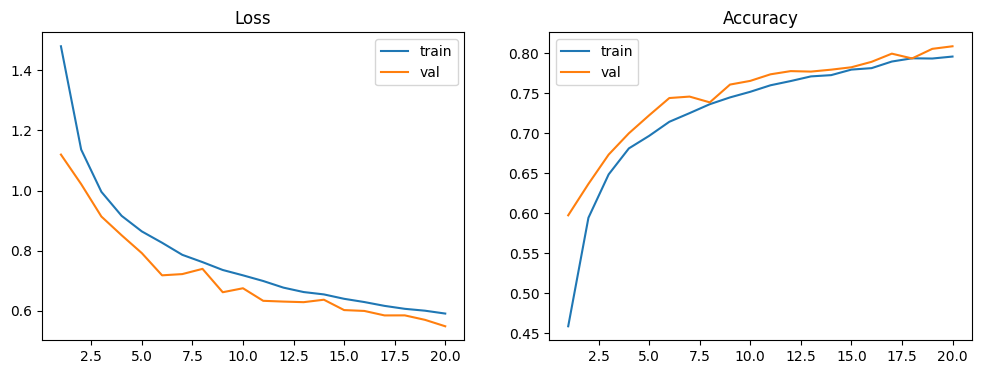

In [88]:
plot_history(results['history']) 

In [85]:
model

CNN(
  (features): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (3): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

## 2.10 Visualize Feature Maps and Kernels

In [ ]:
def visualize_first_layer_filters(model, n_filters=16):
    first_conv = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            first_conv = m
            break

    if first_conv is None:
        print("No Conv2D layer found.")
        return

    W = first_conv.weight.data.cpu()
    n = min(n_filters, W.shape[0])

    plt.figure(figsize=(12, 2.5 * math.ceil(n / 6)))
    for i in range(n):
        f = W[i]
        f = (f - f.min()) / (f.max() - f.min() + 1e-9)
        img = f.permute(1, 2, 0).numpy()
        img = f.mean(dim=0).numpy()  # convert to grayscale by finding the mean of the 3 channels
        
        plt.subplot(math.ceil(n / 6), 6, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Kernel {i}", fontsize=10)
        plt.axis("off")

    plt.subplots_adjust(hspace=0.1, wspace=0.1)
    plt.show()

In [ ]:
def visualize_feature_maps(model, idx, n_maps=8):
    model.eval()
    img, label = test_data[idx]
    
    plt.imshow(unnormalize(img).permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    plt.show()

    img = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        cur = img
        for i, layer in enumerate(model.features):
            cur = layer(cur)
            if i == 0:
                act = cur[0].cpu()
                n = min(n_maps, act.shape[0])

                plt.figure(figsize=(12, 2.5 * math.ceil(n / 6)))
                for j in range(n):
                    fmap = act[j]
                    fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-9)
                    
                    plt.subplot(math.ceil(n / 6), 6, j + 1)
                    plt.imshow(fmap.numpy(), cmap="gray")
                    plt.title(f"Filter {j}", fontsize=10)
                    plt.axis("off")
                    
                plt.subplots_adjust(hspace=0.1, wspace=0.1) 
                plt.show()
                break

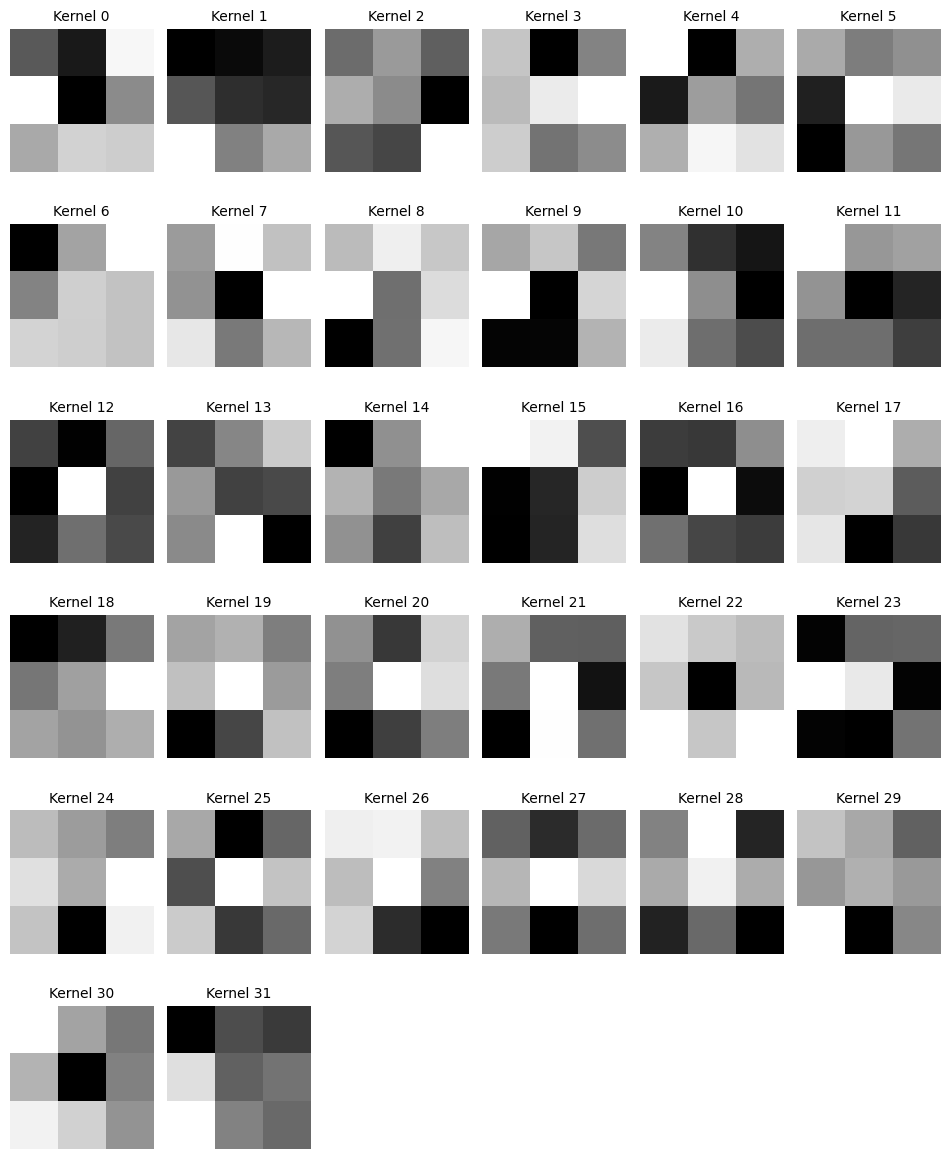

In [217]:
visualize_first_layer_filters(model, n_filters=32)

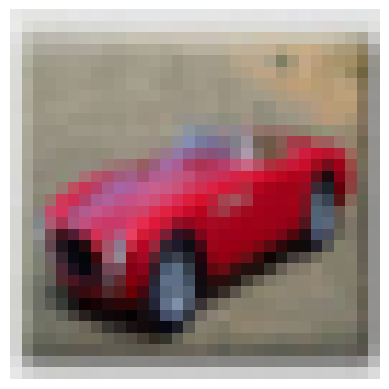

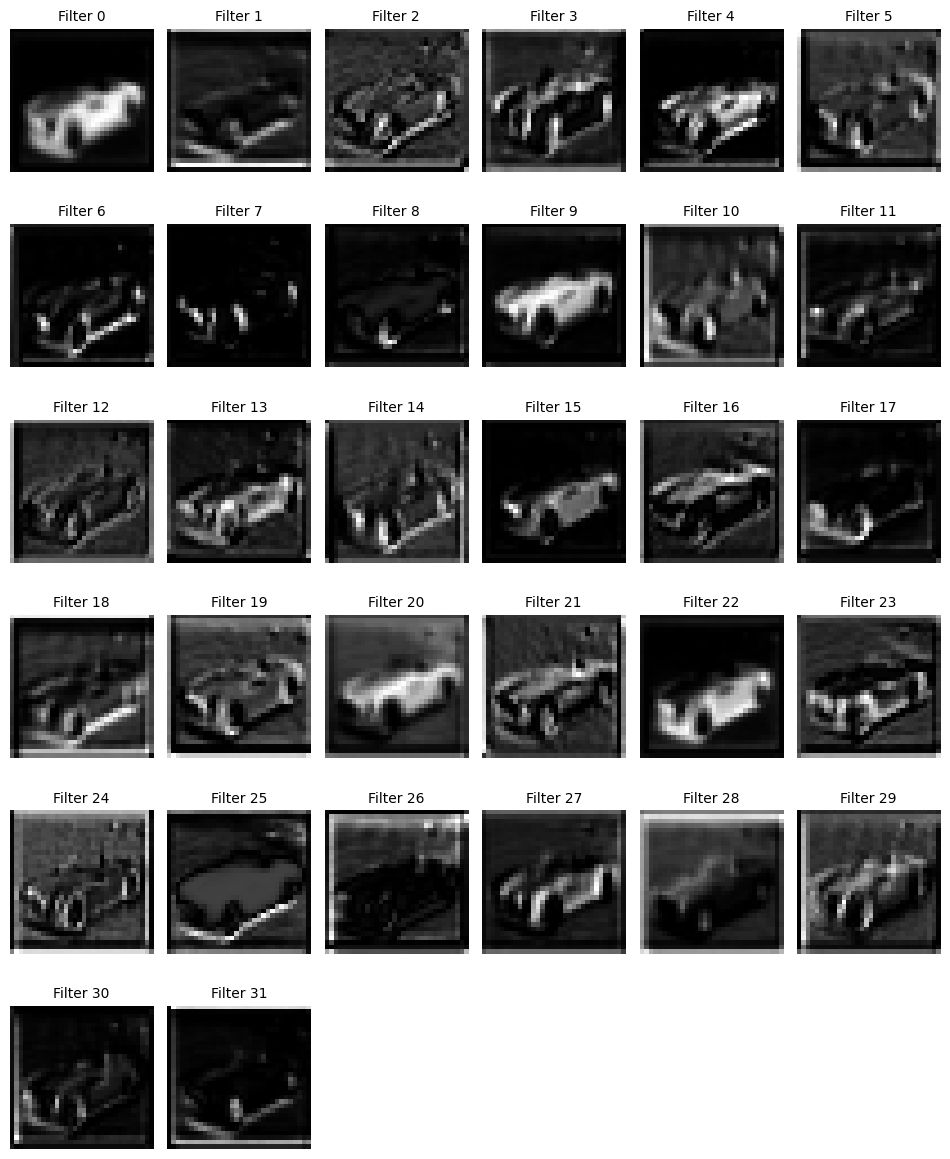

In [218]:
visualize_feature_maps(model, idx=1234, n_maps=32)

## 2.11 Model Prediction Comparison with Ground Truth

In [222]:
CIFAR10_CLASSES = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

In [223]:
def visualize_predictions(model, test_data, x, classes=CIFAR10_CLASSES):
    model.eval()
    correct = 0

    indices = random.sample(range(len(test_data)), x)

    for idx in indices:
        img, label = test_data[idx]

        # Unsqueeze for model: (C,H,W) → (1,C,H,W)
        input_tensor = img.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(input_tensor)
            # predicted_class = torch.argmax(output, dim=1).item()
            probs = torch.softmax(output, dim=1)
            predicted_class = torch.argmax(probs, dim=1).item()
            confidence = probs[0, predicted_class].item() * 100.0

        if predicted_class == label:
            correct += 1

        # Unnormalize image and convert tensor CHW → HWC for plotting
        img_unnorm = unnormalize(img)     # still (C,H,W)
        img_np = img_unnorm.permute(1, 2, 0).numpy().clip(0, 1)

        plt.figure(figsize=(4,4))
        plt.imshow(img_np)
        plt.axis('off')

        plt.title(
            f"Truth: {label} ({classes[label]})\nPred: {predicted_class} ({classes[predicted_class]})\n Confidence: {confidence:.1f}%",
            fontsize=12
        )

        plt.show()

    print(f"Correct predictions: {correct}/{x}")


Choose 5 random samples from the test dataset and compare the model's prediction with the true label

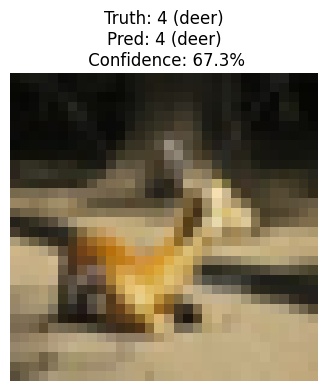

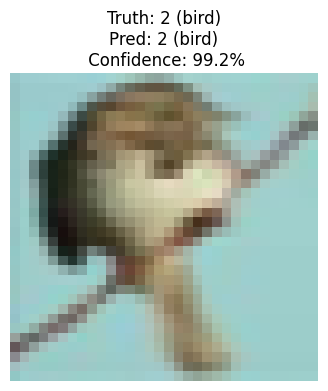

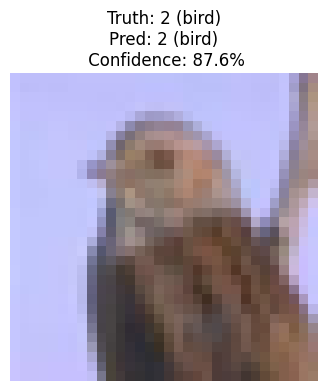

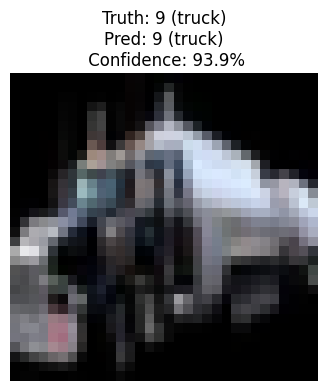

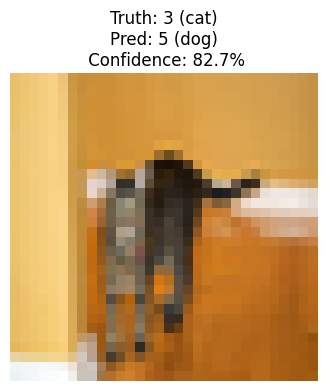

Correct predictions: 4/5


In [112]:
visualize_predictions(model, test_data, 5)

## 2.12 Confusion Matrix

Confusion Matrix for the best model

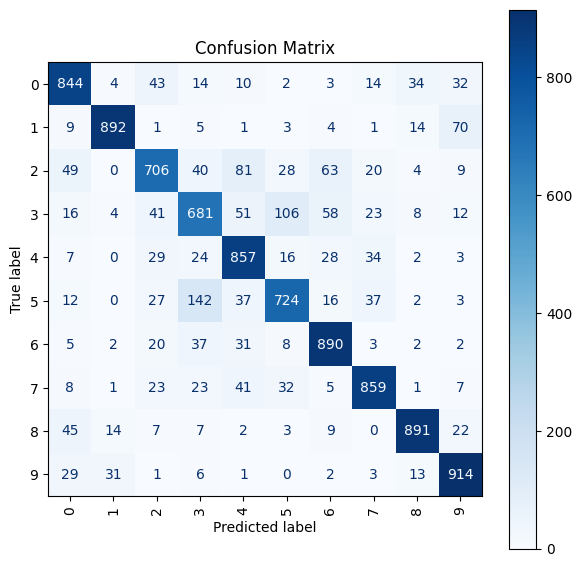

In [140]:
plot_confusion_matrix_cm(y_true=results['test_labels'], y_pred=results['test_preds'], classes=[i for i in range(10)])

## 2.13 Transfer Learning

### ResNet50

In [15]:
class ResNet50(nn.Module):
    def __init__(self, freeze_weights=True, dropout_prob=0.3):
        super().__init__()
        
        self.network = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        if freeze_weights:
            for p in self.network.parameters():
                p.requires_grad = False
        
        flat_size = self.network.fc.in_features        
    
        self.network.fc = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 10),
        )
        
    def forward(self, x):
        return self.network(x)
   

Freeze all CNN weights and only train the linear layers:

In [16]:
resnet_frozen = ResNet50(freeze_weights=True)

In [17]:
results_resnet_frozen = train_and_evaluate(resnet_frozen, trainset=train_subset, valset=val_subset, testset=test_data,
                                    epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

results_resnet_frozen['time_sec']

Epoch  1/10 | train_loss=1.907670 acc=0.330311 | val_loss=1.843375 acc=0.383600


Epoch  2/10 | train_loss=1.829742 acc=0.356644 | val_loss=1.789847 acc=0.394200


Epoch  3/10 | train_loss=1.801947 acc=0.363956 | val_loss=1.825392 acc=0.385000


Epoch  4/10 | train_loss=1.797472 acc=0.362733 | val_loss=1.838960 acc=0.388600


Epoch  5/10 | train_loss=1.784365 acc=0.369822 | val_loss=1.759199 acc=0.410000


...

Epoch  7/10 | train_loss=1.774210 acc=0.374933 | val_loss=1.712761 acc=0.420400


Epoch  8/10 | train_loss=1.780240 acc=0.372822 | val_loss=1.720480 acc=0.412200


Epoch  9/10 | train_loss=1.770580 acc=0.373378 | val_loss=1.702003 acc=0.412200


Epoch 10/10 | train_loss=1.773652 acc=0.373533 | val_loss=1.718138 acc=0.415400

Test: loss=1.608456, acc=0.448500


381.0358099937439

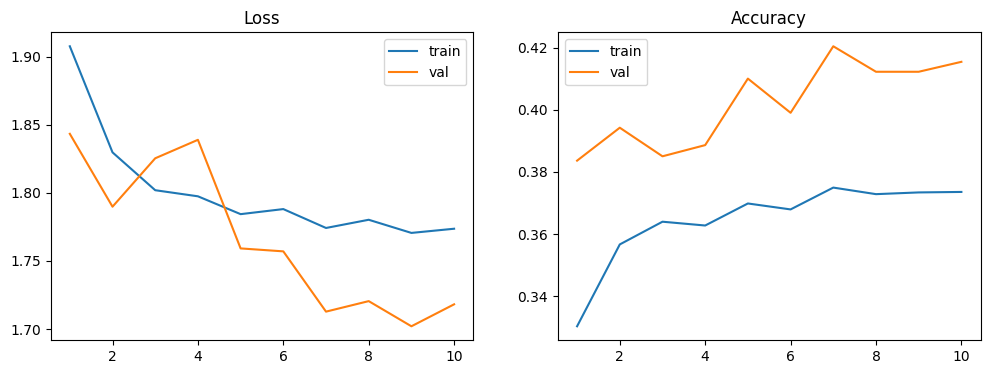

In [18]:
plot_history(results_resnet_frozen['history']) 

Train the entire network without freezing weights:

In [19]:
resnet_fulltrain = ResNet50(freeze_weights=False)

In [20]:
results_resnet_fulltrain = train_and_evaluate(resnet_fulltrain, trainset=train_subset, valset=val_subset, testset=test_data,
                                    epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

results_resnet_fulltrain['time_sec']

Epoch  1/10 | train_loss=1.226461 acc=0.596244 | val_loss=0.884956 acc=0.702600


Epoch  2/10 | train_loss=0.869378 acc=0.719200 | val_loss=0.768577 acc=0.748200


Epoch  3/10 | train_loss=0.766869 acc=0.750778 | val_loss=0.710164 acc=0.768800


Epoch  4/10 | train_loss=0.704983 acc=0.774133 | val_loss=0.632734 acc=0.796400


Epoch  5/10 | train_loss=0.654825 acc=0.789133 | val_loss=0.590590 acc=0.805600


...

Epoch  7/10 | train_loss=0.585299 acc=0.809600 | val_loss=0.597606 acc=0.806200


Epoch  8/10 | train_loss=0.567647 acc=0.818556 | val_loss=0.559098 acc=0.820000


Epoch  9/10 | train_loss=0.547037 acc=0.822222 | val_loss=0.549604 acc=0.821400


Epoch 10/10 | train_loss=0.517758 acc=0.832133 | val_loss=0.548218 acc=0.823600

Test: loss=0.529869, acc=0.829500


645.2460777759552

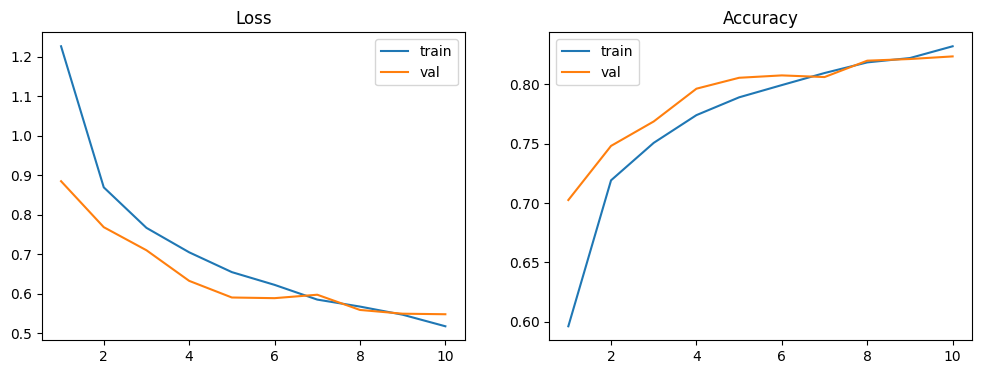

In [21]:
plot_history(results_resnet_fulltrain['history']) 

### EfficientNetB0

In [35]:
class EfficientNetB0(nn.Module):
    def __init__(self, freeze_weights=True, dropout_prob=0.3):
        super().__init__()
        
        self.network = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
   
        if freeze_weights:
            for p in self.network.parameters():
                p.requires_grad = False
        
        flat_size = self.network.classifier[1].in_features        
    
        self.network.classifier[1] = nn.Sequential(
            nn.Linear(flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 10),
        )
        
    def forward(self, x):
        return self.network(x)

Freeze all CNN weights and only train the linear layers:

In [36]:
efficientnet_frozen = EfficientNetB0(freeze_weights=True)

In [24]:
results_efficientnet_frozen = train_and_evaluate(efficientnet_frozen, trainset=train_subset, valset=val_subset, testset=test_data,
                                    epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

results_efficientnet_frozen['time_sec']

Epoch  1/10 | train_loss=1.957779 acc=0.302533 | val_loss=1.873465 acc=0.327600


Epoch  2/10 | train_loss=1.919594 acc=0.314089 | val_loss=1.849842 acc=0.342600


Epoch  3/10 | train_loss=1.907074 acc=0.321978 | val_loss=1.832424 acc=0.349600


Epoch  4/10 | train_loss=1.904082 acc=0.321267 | val_loss=1.828145 acc=0.346000


Epoch  5/10 | train_loss=1.903189 acc=0.321733 | val_loss=1.838494 acc=0.343600


...

Epoch  7/10 | train_loss=1.898179 acc=0.323756 | val_loss=1.828411 acc=0.345800


Epoch  8/10 | train_loss=1.895724 acc=0.324822 | val_loss=1.829959 acc=0.350600


Epoch  9/10 | train_loss=1.897045 acc=0.326200 | val_loss=1.843188 acc=0.350800


Epoch 10/10 | train_loss=1.897219 acc=0.326956 | val_loss=1.815529 acc=0.354800

Test: loss=1.894561, acc=0.321900


448.303017616272

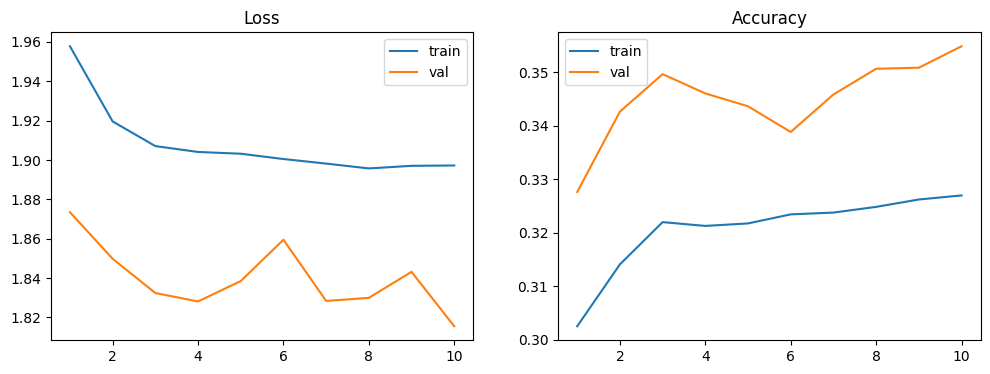

In [25]:
plot_history(results_efficientnet_frozen['history']) 

Train the entire network without freezing weights:

In [26]:
efficientnet_fulltrain = EfficientNetB0(freeze_weights=False)

In [27]:
results_efficientnet_fulltrain = train_and_evaluate(efficientnet_fulltrain, trainset=train_subset, valset=val_subset, testset=test_data,
                                    epochs=10, batch_size=32, lr=0.001, optimizer_name='adam')

results_efficientnet_fulltrain['time_sec']

Epoch  1/10 | train_loss=1.230413 acc=0.578644 | val_loss=0.894117 acc=0.701800


Epoch  2/10 | train_loss=0.915083 acc=0.696556 | val_loss=0.707138 acc=0.763200


Epoch  3/10 | train_loss=0.812138 acc=0.732622 | val_loss=0.676214 acc=0.771200


Epoch  4/10 | train_loss=0.740332 acc=0.754644 | val_loss=0.594551 acc=0.806000


Epoch  5/10 | train_loss=0.731020 acc=0.760111 | val_loss=0.625489 acc=0.786600


...

Epoch  7/10 | train_loss=0.639475 acc=0.788156 | val_loss=0.600080 acc=0.800000


Epoch  8/10 | train_loss=0.611733 acc=0.800822 | val_loss=0.522232 acc=0.824200


Epoch  9/10 | train_loss=0.592352 acc=0.807800 | val_loss=0.562198 acc=0.813200


Epoch 10/10 | train_loss=0.577427 acc=0.810533 | val_loss=0.520010 acc=0.824600

Test: loss=0.510341, acc=0.830400


792.2092561721802

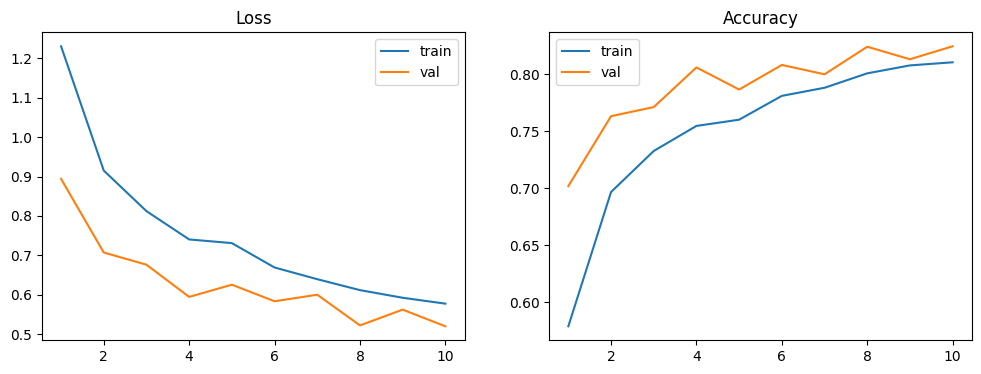

In [28]:
plot_history(results_efficientnet_fulltrain['history']) 

### Comparison

In [34]:
print( 'Test Accuracy Comparison:\n\n' +
       '              Model               | Test Accuracy\n' +
       '---------------------------------------------------\n' +
      f' Custom CNN Model (32-32-32-32)   |  {results['test_acc']} \n' +
      f' ResNet50 - Frozen Weights        |  {results_resnet_frozen['test_acc']} \n' +
      f' ResNet50 - Full Train            |  {results_resnet_fulltrain['test_acc']} \n' +
      f' EfficientNetB0 - Frozen Weights  |  {results_efficientnet_frozen['test_acc']} \n' +
      f' EfficientNetB0 - Full Train      |  {results_efficientnet_fulltrain['test_acc']}')

Test Accuracy Comparison:

              Model               | Test Accuracy
---------------------------------------------------
 Custom CNN Model (32-32-32-32)   |  0.8258 
 ResNet50 - Frozen Weights        |  0.4485 
 ResNet50 - Full Train            |  0.8295 
 EfficientNetB0 - Frozen Weights  |  0.3219 
 EfficientNetB0 - Full Train      |  0.8304
